In [9]:
import matplotlib.pyplot as plt
import itertools as it
import numpy as np
import pandas as pd
from sklearn import linear_model
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [2]:
ape_df = pd.DataFrame({'predicted': [4,2,9], 'actual': [3,5,7]})
ape_df['error'] = ape_df['predicted'] - ape_df['actual']
print(ape_df)

   predicted  actual  error
0          4       3      1
1          2       5     -3
2          9       7      2


In [5]:
def regression_errors(figsize, predicted, actual, errors='all'):
  fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)
  df = pd.DataFrame({'actual':actual, 'predicted':predicted})
  for ax, (x,y) in zip(axes, it.permutations(['actual', 'predicted'])):
    # plot the data as '.'; perfect as y=x line
    ax.plot(df[x], df[y], '.', label='data')
    ax.plot(df['actual'], df['actual'], '-',
      label='perfection')
    ax.legend()
    ax.set_xlabel('{} Value'.format(x.capitalize()))
    ax.set_ylabel('{} Value'.format(y.capitalize()))
    ax.set_aspect('equal')
  axes[1].yaxis.tick_right()
  axes[1].yaxis.set_label_position("right")
  # show connecting bars from data to perfect
  # for all or only those specified?
  if errors == 'all':
    errors = range(len(df))
  if errors:
    acts = df.actual.iloc[errors]
    preds = df.predicted.iloc[errors]
    axes[0].vlines(acts, preds, acts, 'r')
    axes[1].hlines(acts, preds, acts, 'r')

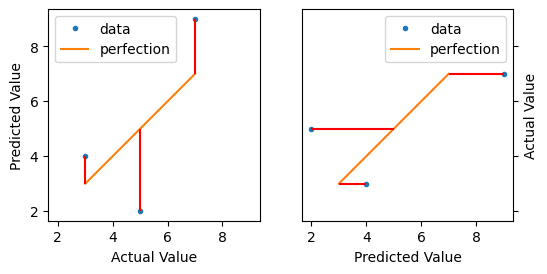

In [8]:
regression_errors((6, 3), ape_df['predicted'], ape_df['actual'])

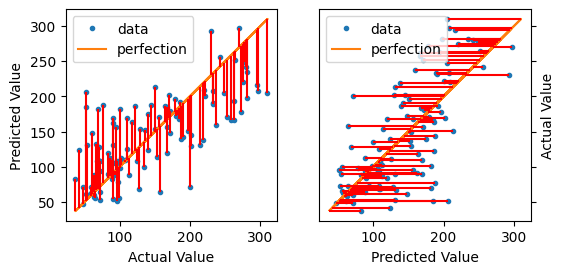

In [10]:
diabetes = datasets.load_diabetes()
train_data, test_data, train_target, test_target = train_test_split(diabetes.data,diabetes.target,test_size=0.25, random_state=42)

lr = linear_model.LinearRegression()
lr.fit(train_data, train_target)
predictions = lr.predict(test_data)
regression_errors((6, 3), predictions, test_target)